In [21]:
import pandas as pd
import warnings
import os

warnings.filterwarnings('ignore')

from codecarbon import EmissionsTracker
tracker = EmissionsTracker(
    log_level="error", 
    save_to_file=True, 
    output_dir=".", 
    output_file="emissions_eda.csv"
)

tracker.start()

df = pd.read_csv('HRDataset_v14.csv')

# --- Phase d'Anonymisation ---
# On applique la suppression et la généralisation comme demandé
df_anon = df.drop(columns=['Employee_Name', 'EmpID', 'ManagerName', 'Zip'])
df_anon['DOB'] = pd.to_datetime(df_anon['DOB'], errors='coerce').dt.year

print("Phase d'anonymisation terminée avec succès.")

Phase d'anonymisation terminée avec succès.



--- Phase d'Analyse Exploratoire ---


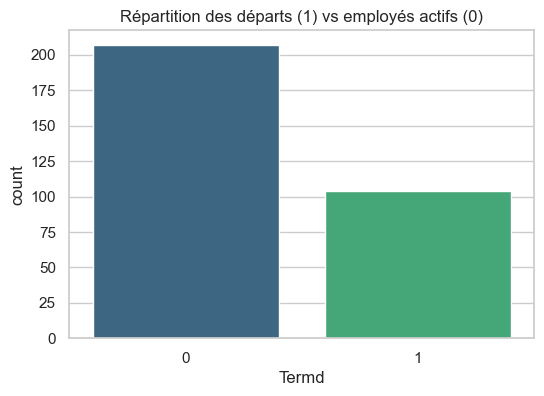

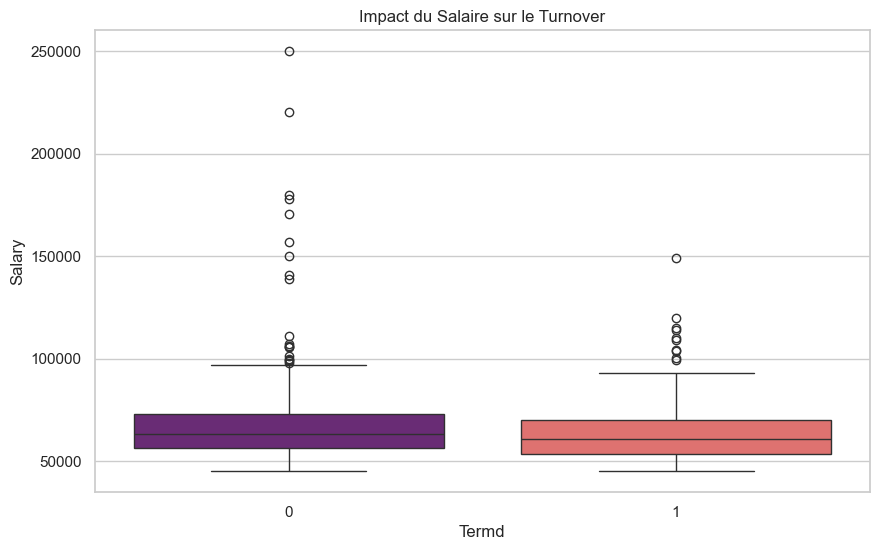

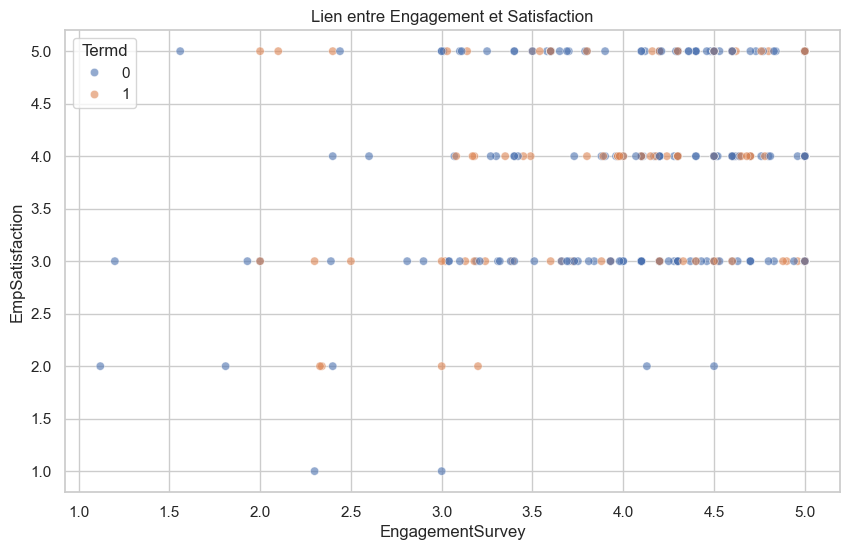

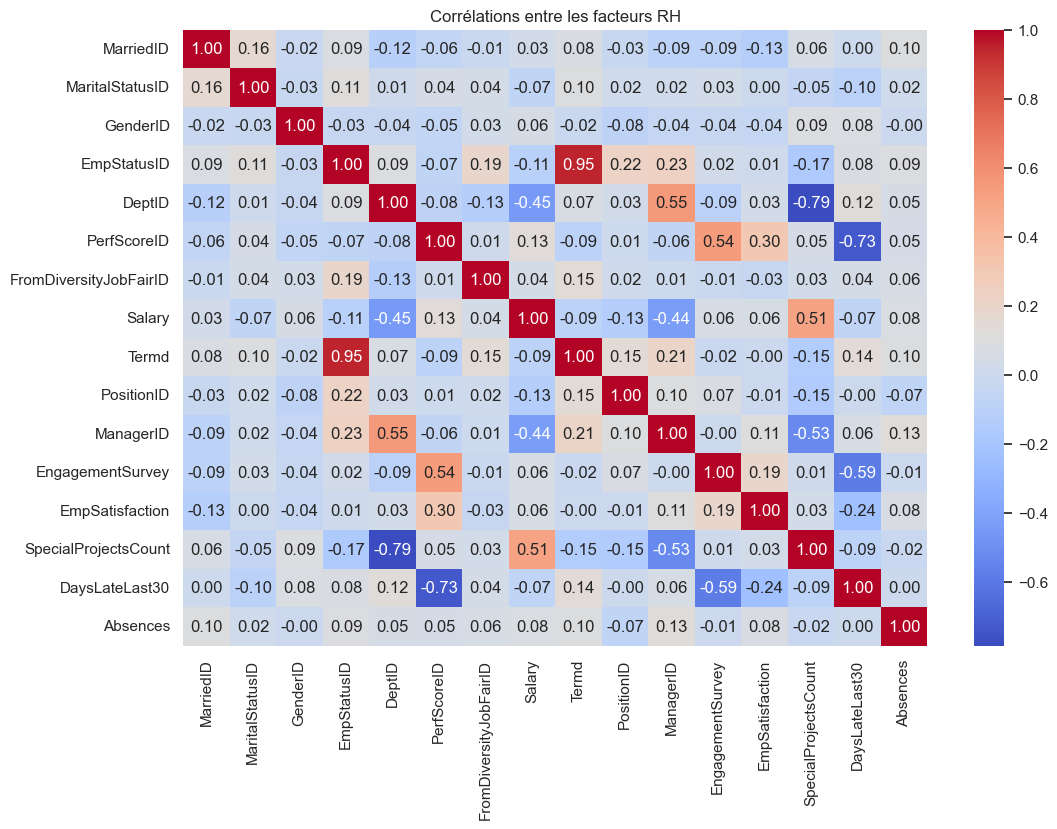

In [22]:
# Exploration
print("\n--- Phase d'Analyse Exploratoire ---")

# Configuration visuelle
sns.set(style="whitegrid")

# 1. Distribution de la variable cible (Termd : 1 = Parti, 0 = En poste) [cite: 46, 127]
plt.figure(figsize=(6, 4))
sns.countplot(data=df_anon, x='Termd', palette='viridis')
plt.title('Répartition des départs (1) vs employés actifs (0)')
plt.savefig('distribution_turnover.png')

# 2. Relation entre le Salaire et le Départ [cite: 32]
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_anon, x='Termd', y='Salary', palette='magma')
plt.title('Impact du Salaire sur le Turnover')
plt.savefig('salary_vs_turnover.png')

# 3. Satisfaction vs Engagement
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_anon, x='EngagementSurvey', y='EmpSatisfaction', hue='Termd', alpha=0.6)
plt.title('Lien entre Engagement et Satisfaction')
plt.savefig('satisfaction_scatter.png')

# 4. Matrice de corrélation (pour les variables numériques)
plt.figure(figsize=(12, 8))
corr = df_anon.select_dtypes(include=['int64', 'float64']).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Corrélations entre les facteurs RH')
plt.savefig('correlation_matrix.png')

In [20]:
# ==========================================
# STEP 4: Sauvegarde et Rapport de Frugalité
# ==========================================

# Sauvegarde du dataset prêt pour le Machine Learning
df_anon.to_csv('HR_anonymized.csv', index=False)
print("\nFichier 'HR_anonymized.csv' généré avec succès.")

# Fin du tracking carbone [cite: 97, 169]
emissions = tracker.stop()
print(f"\n[FRUGALITÉ] Émissions générées pour ce traitement : {emissions:.6f} kg CO2")


Fichier 'HR_anonymized.csv' généré avec succès.

[FRUGALITÉ] Émissions générées pour ce traitement : 0.000003 kg CO2
